# Set-Up

In [ ]:
# Install Requirements

!pip install -r requirements.txt

In [1]:
# Import packages

import os
import json
from glob import glob
from pathlib import Path

import numpy as np
import rasterio
from rasterio.windows import Window, from_bounds
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    transform_bounds,
    Resampling,
)
import matplotlib.pyplot as plt

# Patching

In [3]:
# Config

patch_size = 256               # LiDAR patch pixels 
stride = 128                   # LiDAR stride pixels
valid_threshold = 0.7
num_regions = 10

s2_patch_size = int(round(patch_size / 10))  # 26 px @ 10 m  (≈260 m)

# Set paths to your raw data and desired output directories
REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
s2_dir = os.path.join(REPO_DIR, "raw_data", "tuk_sentinel_downloads")
lidar_path = os.path.join(REPO_DIR, "raw_data", "tuk_2024.tif")

out_lidar_dir = os.path.join(REPO_DIR, "input_data", "lidar_patches_tuk")
out_s2_dir = os.path.join(REPO_DIR, "input_data", "s2_patches_tuk")
os.makedirs(out_lidar_dir, exist_ok=True)
os.makedirs(out_s2_dir, exist_ok=True)

In [ ]:
# Helpers 

def check_s2_grid(granule_dir: str, band: str = "B04"):
    """Return (crs, transform, res) for a 10m band inside a granule dir."""
    pattern = os.path.join(granule_dir, "**", f"*_{band}_10m.jp2")
    matches = glob(pattern, recursive=True)
    if not matches:
        raise FileNotFoundError(f"Could not find {band} 10m JP2 in {granule_dir}")
    with rasterio.open(matches[0]) as ds:
        return ds.crs, ds.transform, ds.res


def warp_array_to_crs(
    src_array: np.ndarray,
    src_transform,
    src_crs,
    dst_crs,
    dst_resolution=(1.0, 1.0),
    src_nodata=None,
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
):
    """
    Warp a single-band array to dst_crs with given dst_resolution.
    Returns (dst_array, dst_transform).
    """
    height, width = src_array.shape
    left, bottom, right, top = rasterio.transform.array_bounds(height, width, src_transform)

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, dst_crs, width, height, left, bottom, right, top, resolution=dst_resolution
    )

    dst = np.full((dst_height, dst_width), dst_nodata, dtype=np.float32)

    reproject(
        source=src_array.astype(np.float32),
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        src_nodata=src_nodata,
        dst_nodata=dst_nodata,
        resampling=resampling,
    )
    return dst, dst_transform


def stack_sentinel_bands(granule_path: str):
    """
    Load 4x10m bands into a (4,H,W) stack.
    Order: [B04, B03, B02, B08]  (RGB+NIR style)
    """
    band_files = {}
    for band in ["B02", "B03", "B04", "B08"]:
        pattern = os.path.join(granule_path, "**", f"*_{band}_10m.jp2")
        matches = glob(pattern, recursive=True)
        if not matches:
            raise FileNotFoundError(f"Could not find band {band} in {granule_path}")
        band_files[band] = matches[0]

    band_stack = []
    meta = None
    for band in ["B04", "B03", "B02", "B08"]:
        with rasterio.open(band_files[band]) as src:
            band_stack.append(src.read(1))
            if meta is None:
                meta = src.meta.copy()

    stacked = np.stack(band_stack, axis=0)
    return stacked, meta


def load_json_safe(path: str):
    if path is None or not os.path.exists(path):
        return None
    with open(path, "r") as f:
        return json.load(f)


def build_s2_products(s2_dir: str):
    """
    Discover SAFE folders, build granule dirs, stack bands, and attach metadata JSONs.
    """
    s2_safes = [d for d in Path(s2_dir).iterdir() if d.is_dir()]
    s2_safes = sorted(s2_safes)

    sentinel_meta_jsons = [str(sf) + "_metadata.json" for sf in s2_safes]

    sentinel_granule_dirs = []
    for s2_safe in s2_safes:
        # Find the GRANULE folder robustly
        granule_root = None
        for p in s2_safe.rglob("GRANULE"):
            if p.is_dir():
                granule_root = p
                break
        if granule_root is None:
            raise FileNotFoundError(f"No GRANULE dir found under {s2_safe}")

        # pick the first granule folder under GRANULE
        granules = [g for g in granule_root.iterdir() if g.is_dir()]
        if not granules:
            raise FileNotFoundError(f"No granule folders inside {granule_root}")
        sentinel_granule_dirs.append(str(granules[0]))

    # keep a deterministic product order
    sentinel_granule_dirs = sorted(sentinel_granule_dirs)

    sentinel_products = []
    for i, gdir in enumerate(sentinel_granule_dirs):
        stack, meta = stack_sentinel_bands(gdir)
        sentinel_products.append(
            {
                "stack": stack,
                "meta": meta,
                "transform": meta["transform"],
                "crs": meta["crs"],
                "attrs": load_json_safe(sentinel_meta_jsons[i]),
            }
        )

    base = sentinel_products[0]
    for p in sentinel_products[1:]:
        if p["crs"] != base["crs"]:
            raise ValueError("S2 products have different CRS; windowing may misalign across time.")
        if p["transform"] != base["transform"]:
            raise ValueError("S2 products have different transforms; windowing may misalign across time.")
    return sentinel_products, sentinel_granule_dirs


def compute_valid_patch_positions(lidar_array: np.ndarray, patch_size: int, stride: int, valid_threshold: float):
    """
    Return list of (x, y) window offsets for patches with >= valid_threshold finite pixels.
    """
    H, W = lidar_array.shape
    mask = np.isfinite(lidar_array)
    patches = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch_mask = mask[y : y + patch_size, x : x + patch_size]
            if patch_mask.mean() >= valid_threshold:
                patches.append((x, y))
    return patches


def split_into_x_balanced_regions(patches, num_regions: int):
    """
    Deterministic, count-balanced region split by sorting patch x offsets and splitting into bins.
    """
    patches = np.array(patches, dtype=np.int64)
    sorted_patches = patches[np.argsort(patches[:, 0])]
    patch_bins = np.array_split(sorted_patches, num_regions)
    return [list(map(tuple, b)) for b in patch_bins]


def extract_lidar_multi_s2_by_region(
    lidar_array: np.ndarray,
    lidar_transform,
    lidar_crs,
    sentinel_products,
    patch_size: int,
    s2_patch_size: int,
    valid_threshold: float,
    out_lidar_dir: str,
    out_s2_dir: str,
    region_patch_indices,
    start_idx: int = 0,
):
    """
    Extract LiDAR patches and aligned S2 patches for each region.
    Returns number of extracted patches.
    """
    print("Extracting patches by region...")

    H, W = lidar_array.shape
    count = 0

    for region_id, patch_list in enumerate(region_patch_indices):
        for x, y in patch_list:
            # LiDAR patch
            lid_patch_raw = lidar_array[y : y + patch_size, x : x + patch_size]
            valid_mask = np.isfinite(lid_patch_raw)
            if valid_mask.mean() < valid_threshold:
                continue

            lid_patch = np.nan_to_num(lid_patch_raw, nan=0.0).astype(np.float32)
            lid_mask = valid_mask.astype(np.uint8)
            lidar_patch = np.stack([lid_patch, lid_mask.astype(np.float32)], axis=0)  # (2,H,W)

            # bounds of this LiDAR window in map coords
            lid_win = Window(x, y, patch_size, patch_size)
            lid_bounds = rasterio.windows.bounds(lid_win, lidar_transform)

            # extract aligned S2 patches (one per product)
            s2_patches, s2_transforms = [], []
            ok = True

            for prod in sentinel_products:
                try:
                    # transform LiDAR bounds to S2 CRS 
                    s2_bounds = transform_bounds(lidar_crs, prod["crs"], *lid_bounds, densify_pts=21)

                    # convert bounds -> pixel window, then round to avoid float truncation drift
                    s2_window = from_bounds(*s2_bounds, transform=prod["transform"])
                    s2_window = s2_window.round_offsets().round_lengths()

                    r0, c0 = int(s2_window.row_off), int(s2_window.col_off)
                    hh, ww = int(s2_window.height), int(s2_window.width)

                    # require exact 26x26
                    if (hh, ww) != (s2_patch_size, s2_patch_size):
                        ok = False
                        break

                    # bounds check
                    if r0 < 0 or c0 < 0:
                        ok = False
                        break
                    if r0 + s2_patch_size > prod["stack"].shape[1]:
                        ok = False
                        break
                    if c0 + s2_patch_size > prod["stack"].shape[2]:
                        ok = False
                        break

                    s2_patch = prod["stack"][:, r0 : r0 + s2_patch_size, c0 : c0 + s2_patch_size]
                    if s2_patch.shape[1:] != (s2_patch_size, s2_patch_size):
                        ok = False
                        break

                    s2_patches.append(s2_patch)
                    s2_transforms.append(rasterio.windows.transform(s2_window, prod["transform"]))

                except Exception:
                    ok = False
                    break

            if not ok or len(s2_patches) != len(sentinel_products):
                continue

            # write outputs
            patch_id = f"{start_idx + count:05d}"

            # LiDAR GeoTIFF (2 bands)
            lid_out = os.path.join(out_lidar_dir, f"lidar_patch_{patch_id}.tif")
            lid_meta = {
                "driver": "GTiff",
                "height": patch_size,
                "width": patch_size,
                "count": 2,
                "dtype": "float32",
                "crs": lidar_crs,
                "transform": rasterio.windows.transform(lid_win, lidar_transform),
            }
            with rasterio.open(lid_out, "w", **lid_meta) as dst:
                dst.write(lidar_patch.astype(np.float32))

            # S2 directory with 6 time slices
            patch_dir = os.path.join(out_s2_dir, f"s2_patch_{patch_id}")
            os.makedirs(patch_dir, exist_ok=True)

            attrs_list = []
            for ti, (prod, s2_patch, s2_tr) in enumerate(zip(sentinel_products, s2_patches, s2_transforms)):
                s2_meta = prod["meta"].copy()
                s2_meta.update(
                    {
                        "driver": "GTiff",
                        "count": 4,
                        "height": s2_patch_size,
                        "width": s2_patch_size,
                        "transform": s2_tr,
                    }
                )

                s2_path = os.path.join(patch_dir, f"t{ti}.tif")
                with rasterio.open(s2_path, "w", **s2_meta) as dst:
                    dst.write(s2_patch)

                record = None
                if prod.get("attrs"):
                    a = prod["attrs"]
                    record = {
                        "product_id": a.get("product_id") or a.get("productId"),
                        "product_name": a.get("product_name") or a.get("productName"),
                        "acquisition_date": a.get("acquisition_date"),
                        "cloud_cover": a.get("cloud_cover"),
                        "sun_zenith_mean": a.get("sun_zenith_mean"),
                        "sun_azimuth_mean": a.get("sun_azimuth_mean"),
                        "view_zenith_mean": a.get("view_zenith_mean"),
                        "view_azimuth_mean": a.get("view_azimuth_mean"),
                    }
                attrs_list.append(record)

            with open(os.path.join(patch_dir, "attrs.json"), "w") as jf:
                json.dump(attrs_list, jf, indent=2)

            with open(os.path.join(patch_dir, "region.json"), "w") as jf:
                json.dump({"region_id": region_id+10}, jf)

            count += 1
            if count % 500 == 0:
                print(f"Processed {count} patches...")

    return count

Target S2 CRS: EPSG:32608
Target S2 res: (10.0, 10.0)
Total valid patches: 1676
Balanced Patch Counts:
Region 0: 168 patches
Region 1: 168 patches
Region 2: 168 patches
Region 3: 168 patches
Region 4: 168 patches
Region 5: 168 patches
Region 6: 167 patches
Region 7: 167 patches
Region 8: 167 patches
Region 9: 167 patches


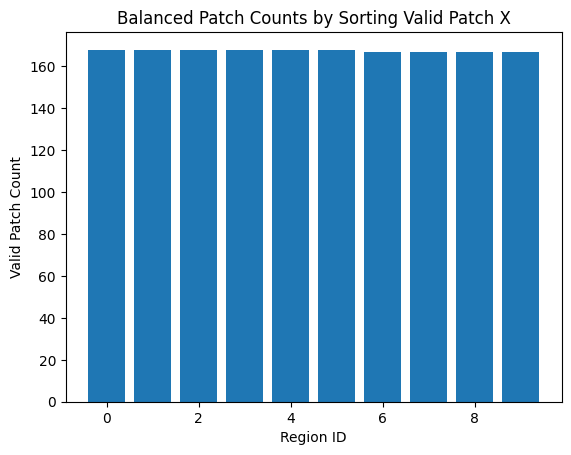

Extracting patches by region...
Processed 500 patches...
Processed 1000 patches...
Processed 1500 patches...
Extracted 1676 LiDAR patches across 10 regions.


In [ ]:
# =================================
# PATCH EXECUTION
# =================================

# Load S2 products + get target CRS/grid
sentinel_products, sentinel_granule_dirs = build_s2_products(s2_dir)
target_crs, target_transform, target_res = check_s2_grid(sentinel_granule_dirs[0], band="B04")
print("Target S2 CRS:", target_crs)
print("Target S2 res:", target_res)  

# Load LiDAR
with rasterio.open(lidar_path) as src:
    lidar_array = src.read(1).astype(np.float32)
    lidar_transform = src.transform
    lidar_crs = src.crs
    nod = src.nodata

# mask nodata + non-finite -> NaN
if nod is not None:
    lidar_array = np.where(lidar_array == nod, np.nan, lidar_array)
lidar_array = np.where(np.isfinite(lidar_array), lidar_array, np.nan)

# Warp LiDAR to S2 CRS (keep ~1m grid)
lidar_array, lidar_transform = warp_array_to_crs(
    src_array=lidar_array,
    src_transform=lidar_transform,
    src_crs=lidar_crs,
    dst_crs=target_crs,
    dst_resolution=(1.0, 1.0),
    src_nodata=nod,         
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)
lidar_crs = target_crs

# Find valid LiDAR patch positions
patches = compute_valid_patch_positions(lidar_array, patch_size, stride, valid_threshold)
print(f"Total valid patches: {len(patches)}")

# Split into regions (balanced by x)
region_patch_indices = split_into_x_balanced_regions(patches, num_regions)
region_patch_counts = [len(r) for r in region_patch_indices]
print("Balanced Patch Counts:")
for i, c in enumerate(region_patch_counts):
    print(f"Region {i}: {c} patches")

plt.bar(range(num_regions), region_patch_counts)
plt.xlabel("Region ID")
plt.ylabel("Valid Patch Count")
plt.title("Balanced Patch Counts by Sorting Valid Patch X")
plt.show()

# Extract + write patches
total = extract_lidar_multi_s2_by_region(
    lidar_array=lidar_array,
    lidar_transform=lidar_transform,
    lidar_crs=lidar_crs,
    sentinel_products=sentinel_products,
    patch_size=patch_size,
    s2_patch_size=s2_patch_size,
    valid_threshold=valid_threshold,
    out_lidar_dir=out_lidar_dir,
    out_s2_dir=out_s2_dir,
    region_patch_indices=region_patch_indices,
    start_idx=12000,
)

print(f"Extracted {total} LiDAR patches across {num_regions} regions.")

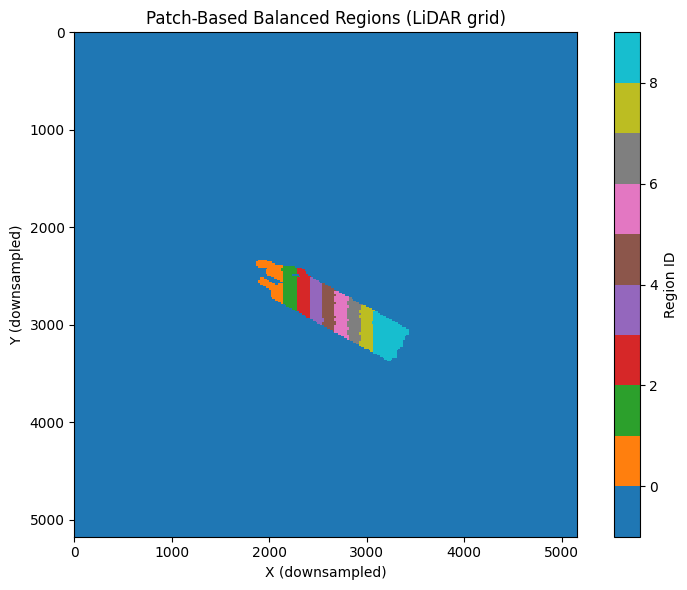

In [ ]:
# Region overlay visualization

# Create an integer map the size of the LiDAR raster
overlay = np.full(lidar_array.shape, -1, dtype=np.int16)

for region_id, patch_list in enumerate(region_patch_indices):
    for x, y in patch_list:
        overlay[y:y + patch_size, x:x + patch_size] = region_id

# Downsample for fast plotting 
ds = 8 
overlay_vis = overlay[::ds, ::ds]

plt.figure(figsize=(8, 6))
im = plt.imshow(overlay_vis, cmap="tab10", interpolation="nearest")
plt.title("Patch-Based Balanced Regions (LiDAR grid)")
plt.xlabel("X (downsampled)")
plt.ylabel("Y (downsampled)")
plt.colorbar(im, label="Region ID")
plt.tight_layout()
plt.show()


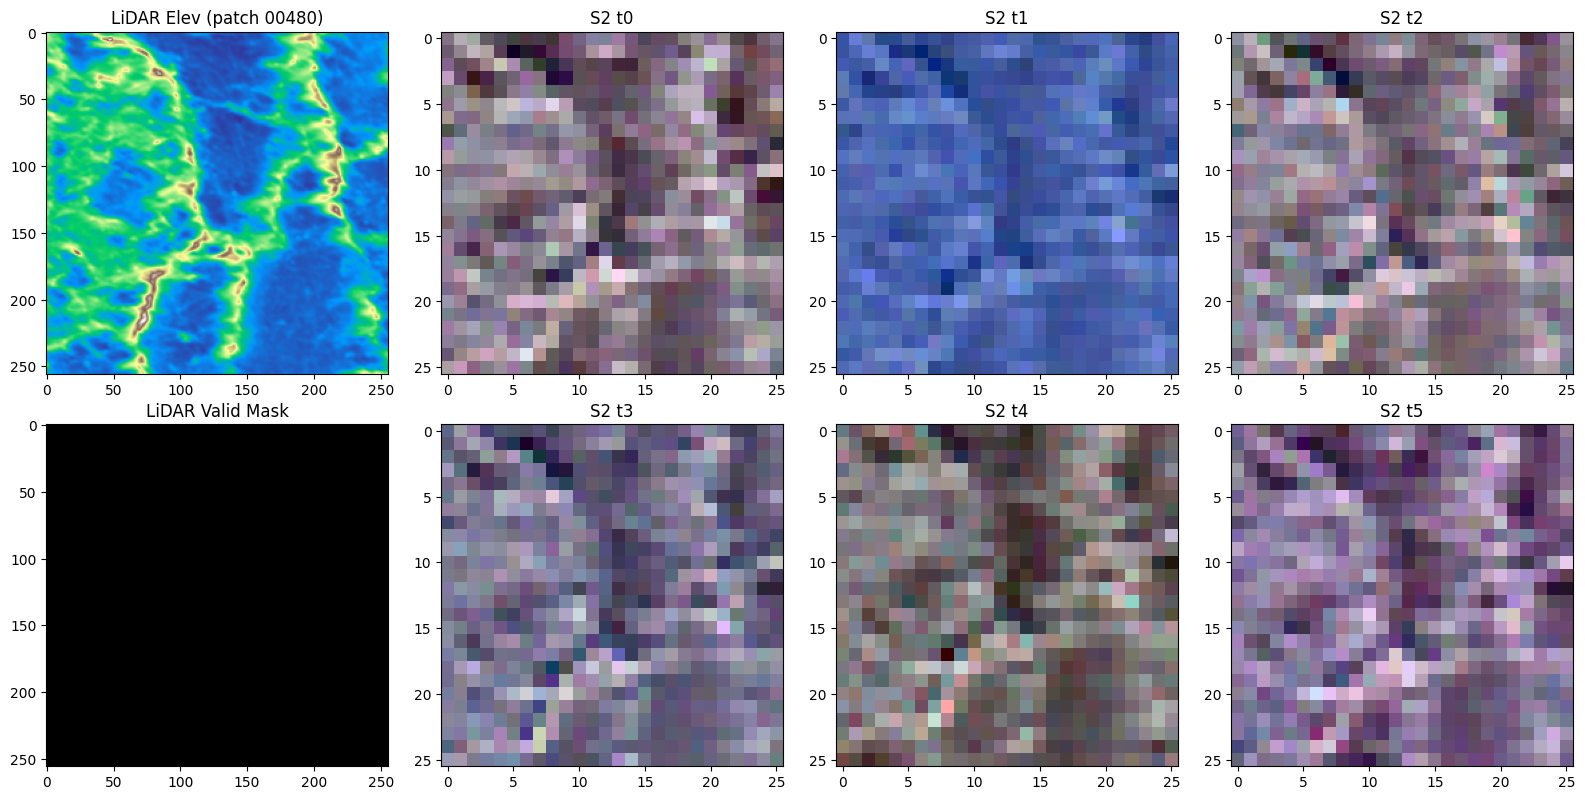

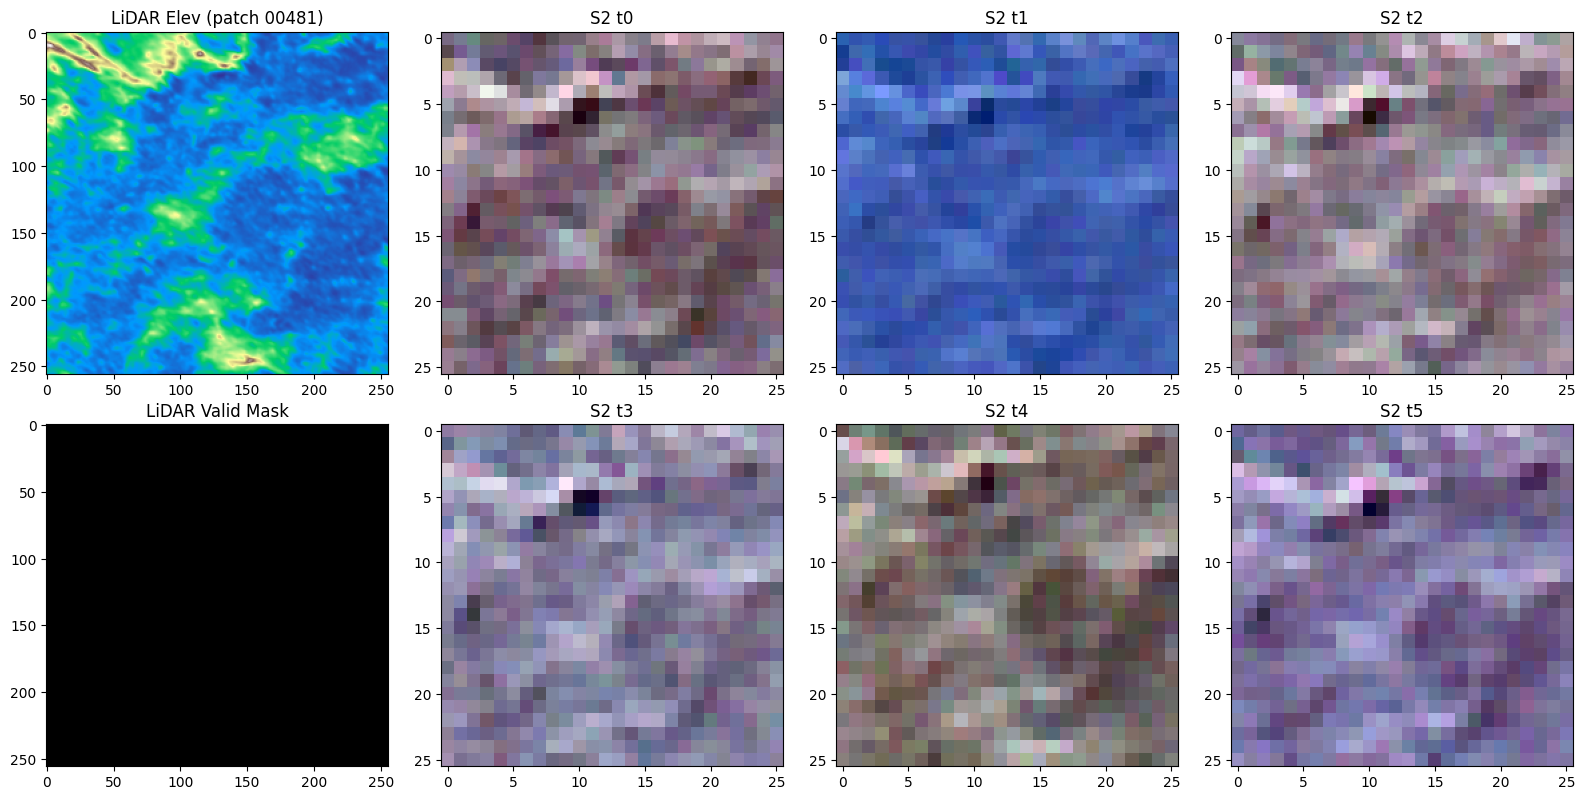

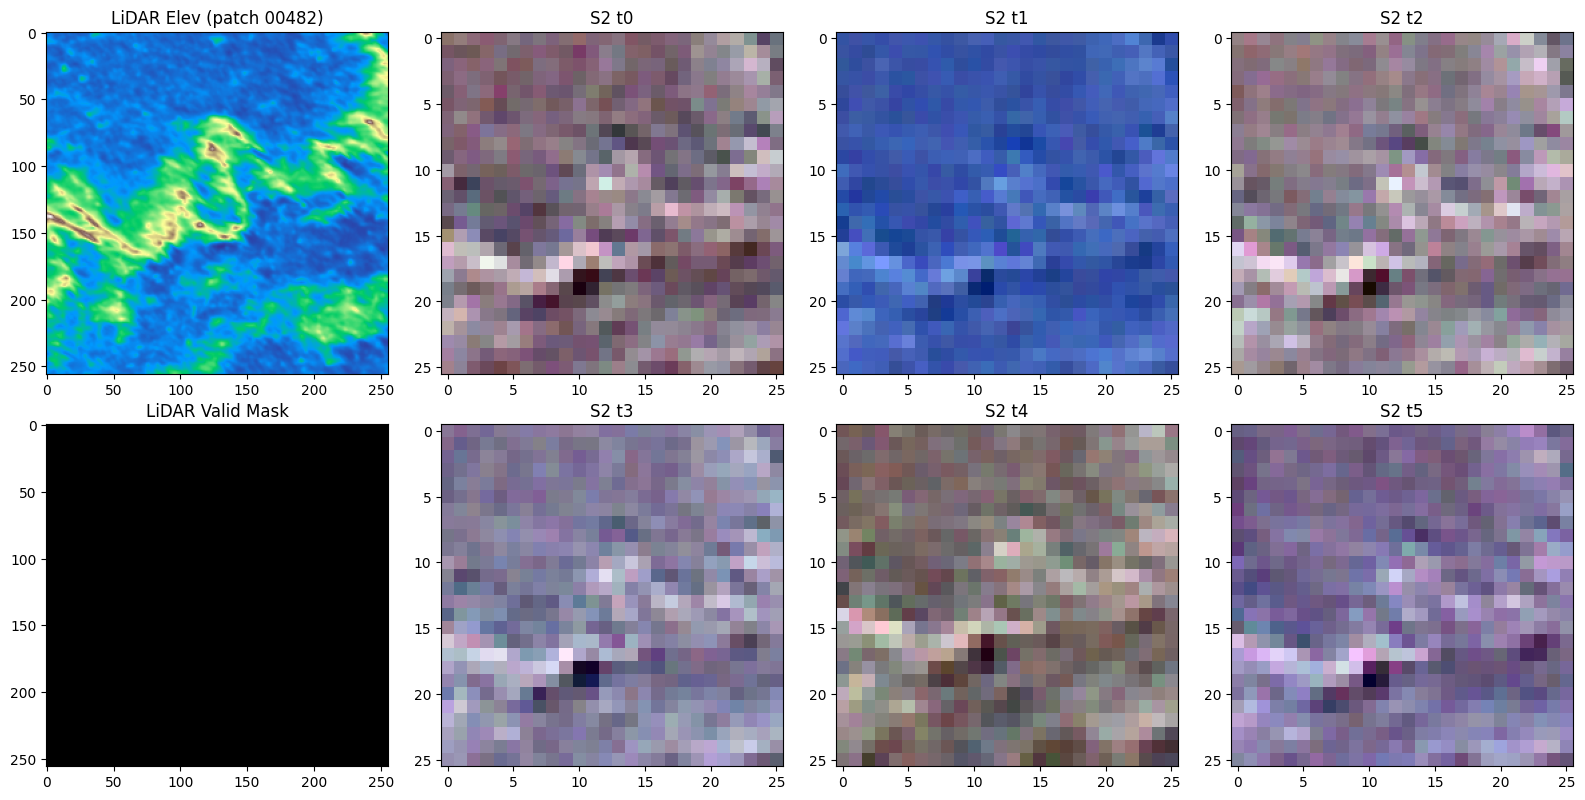

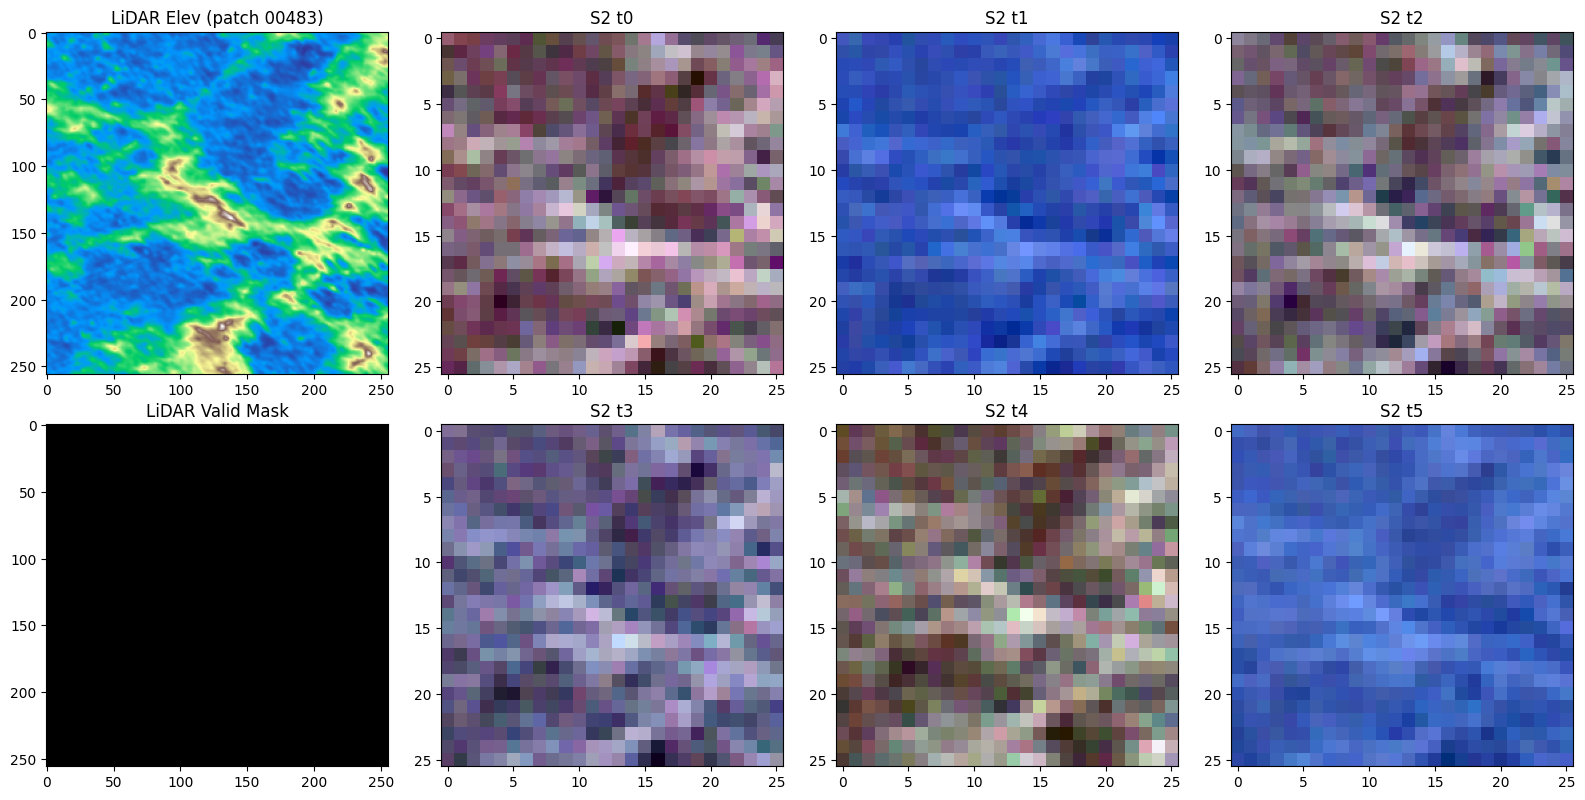

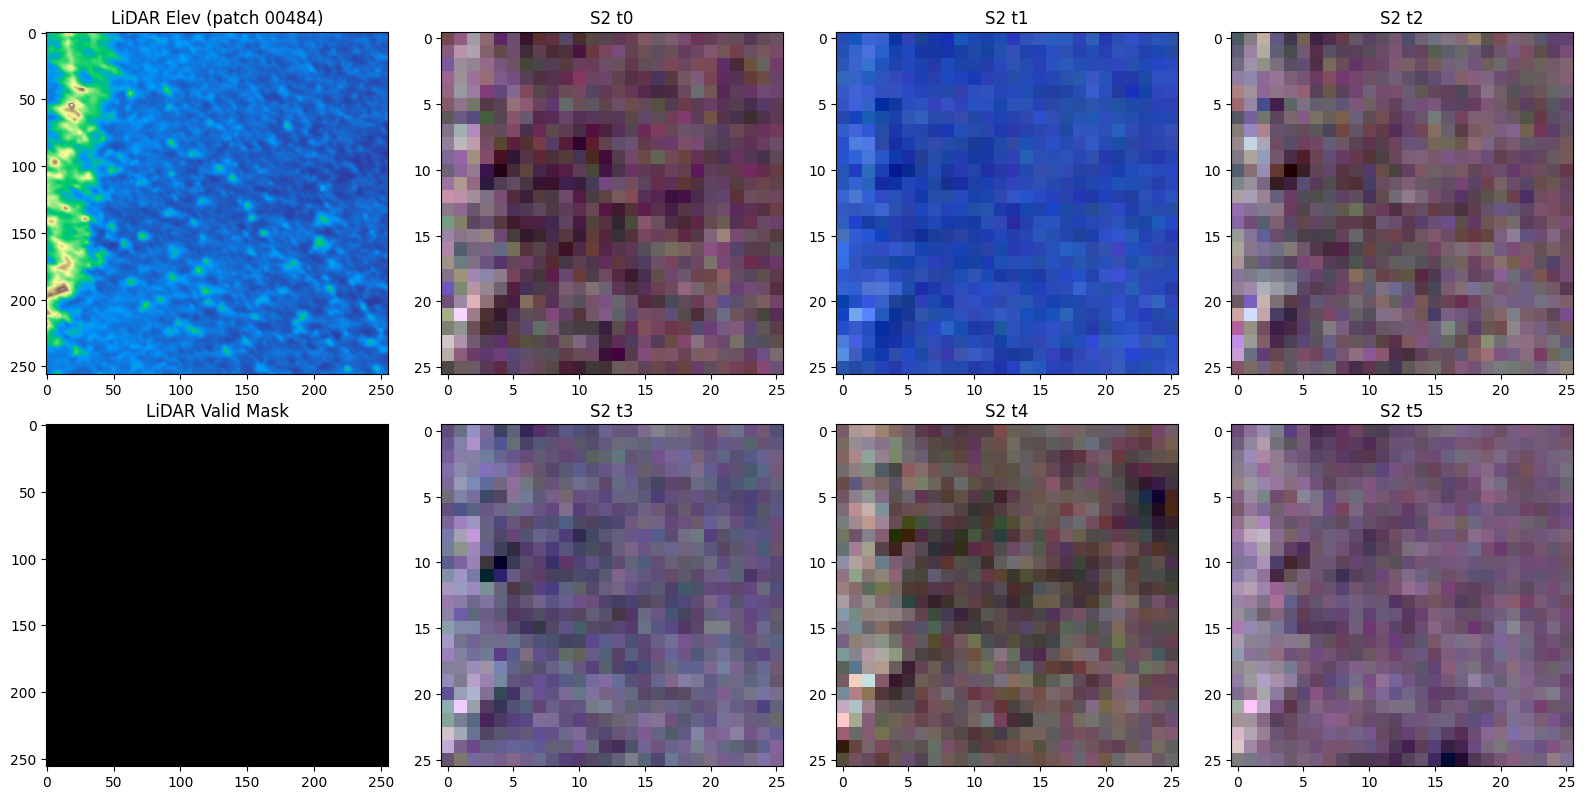

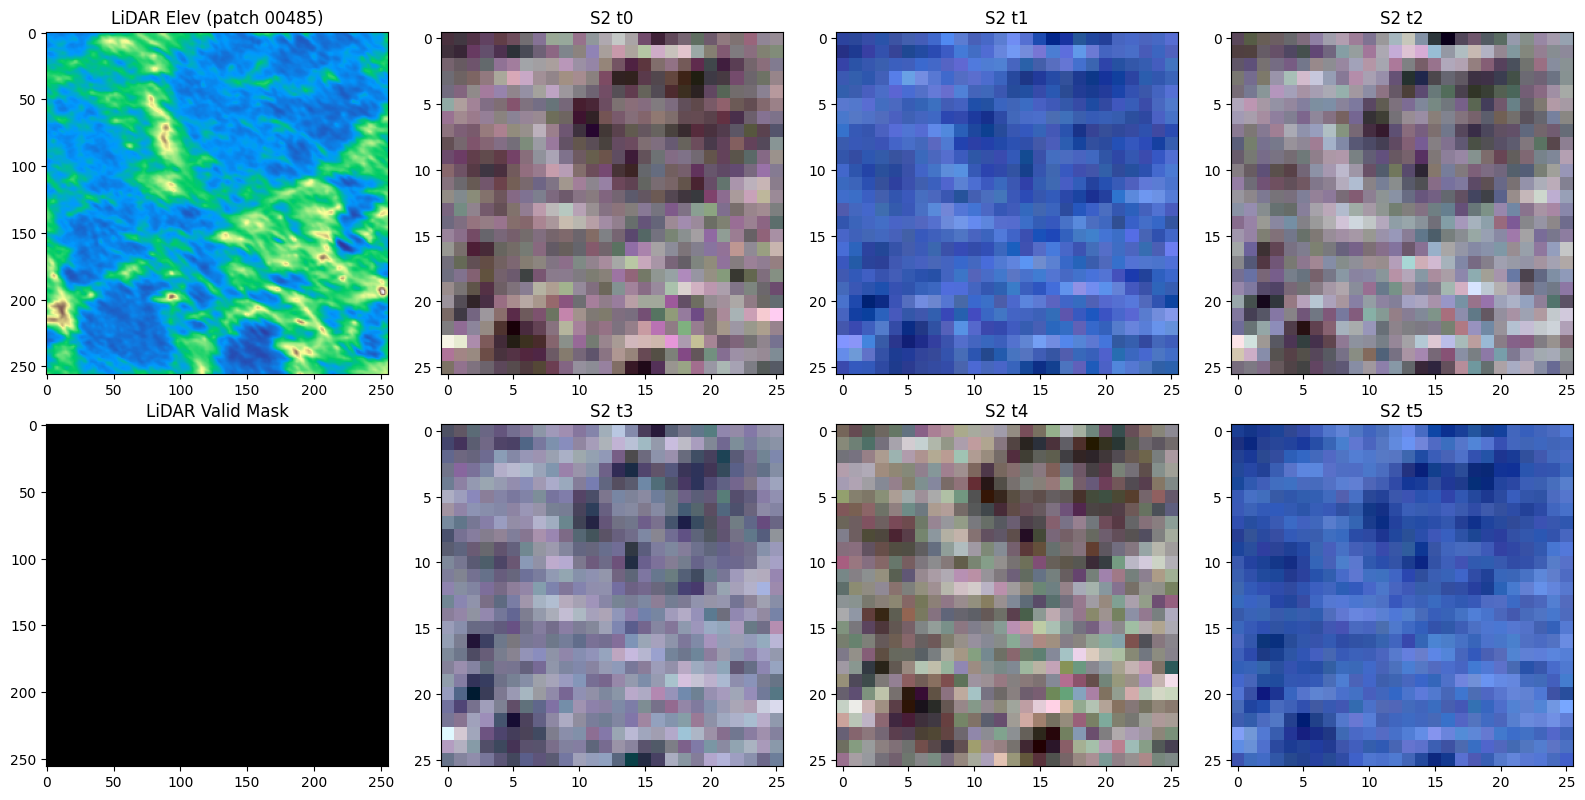

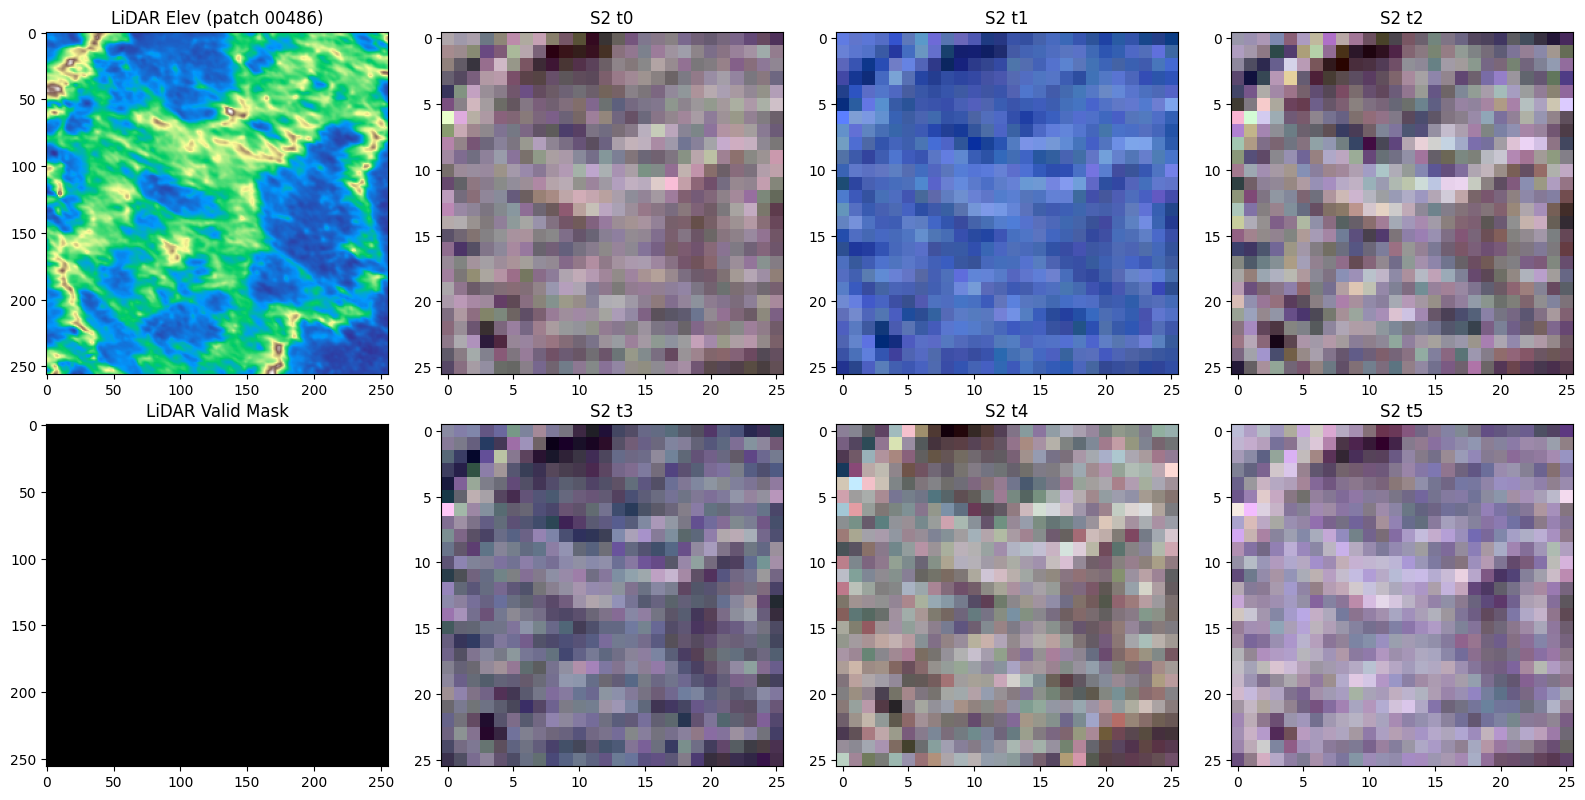

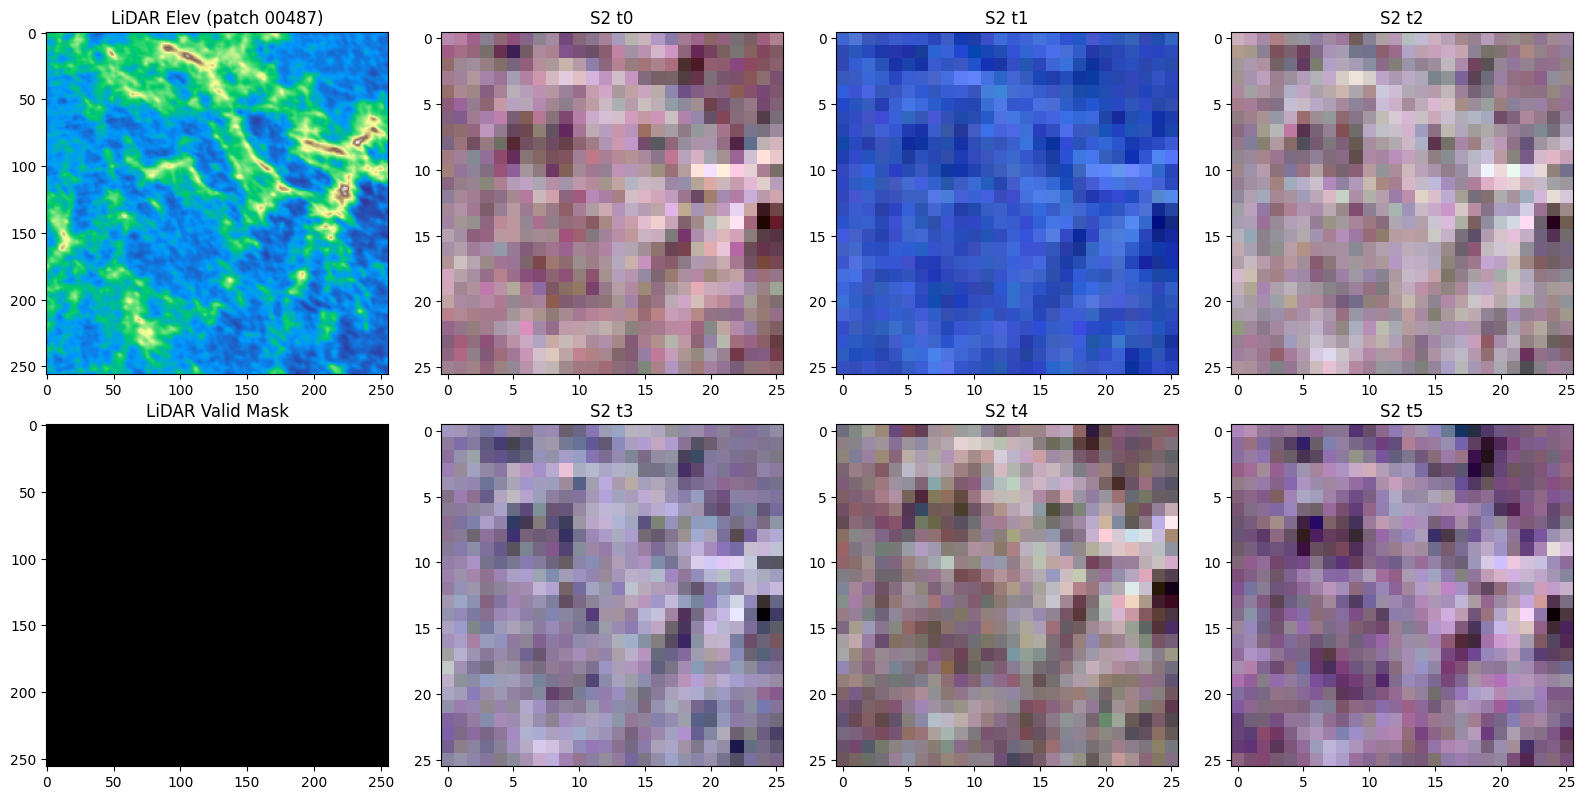

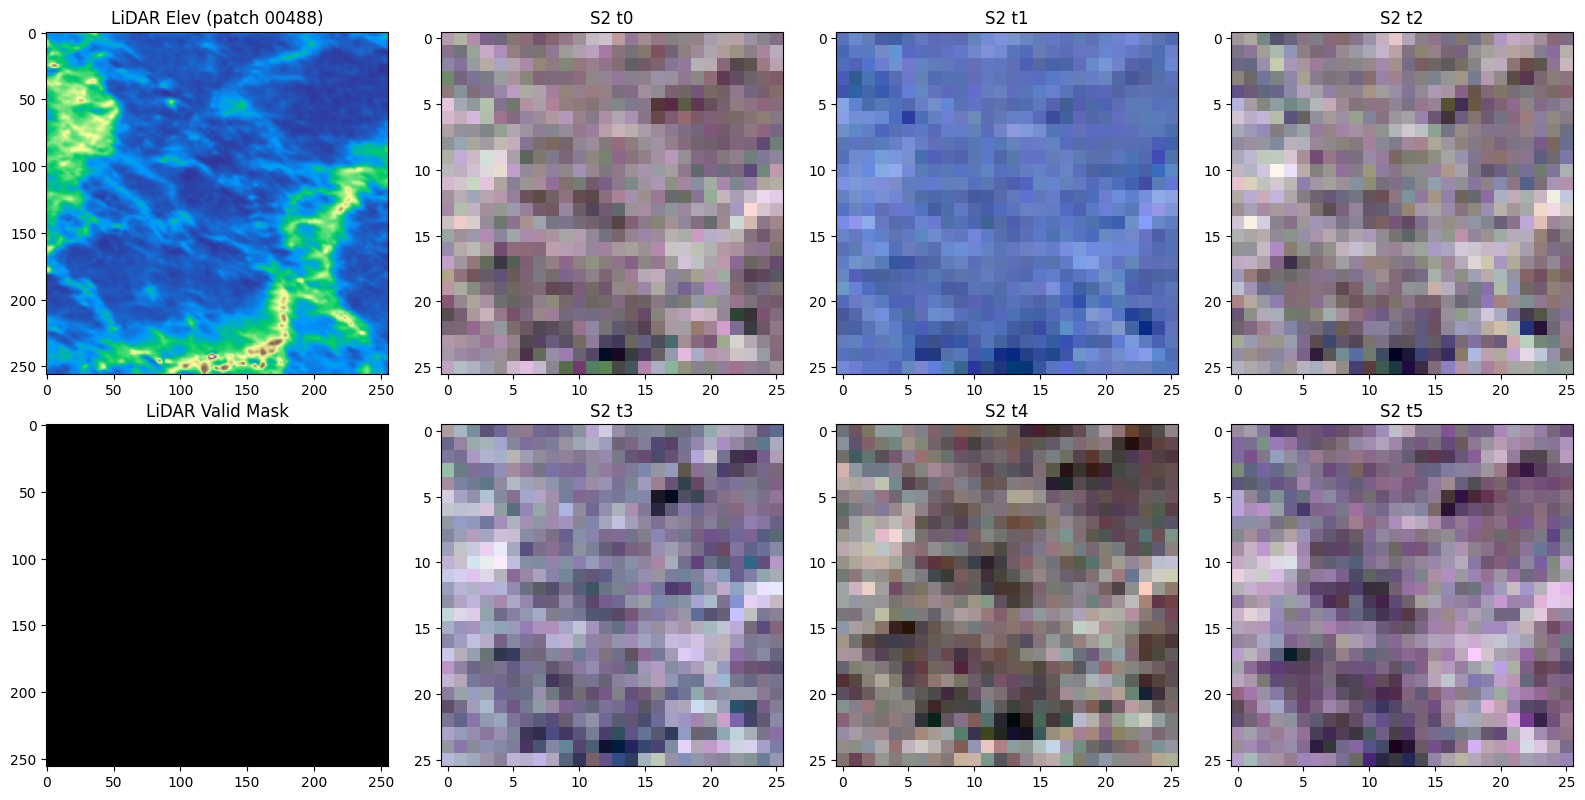

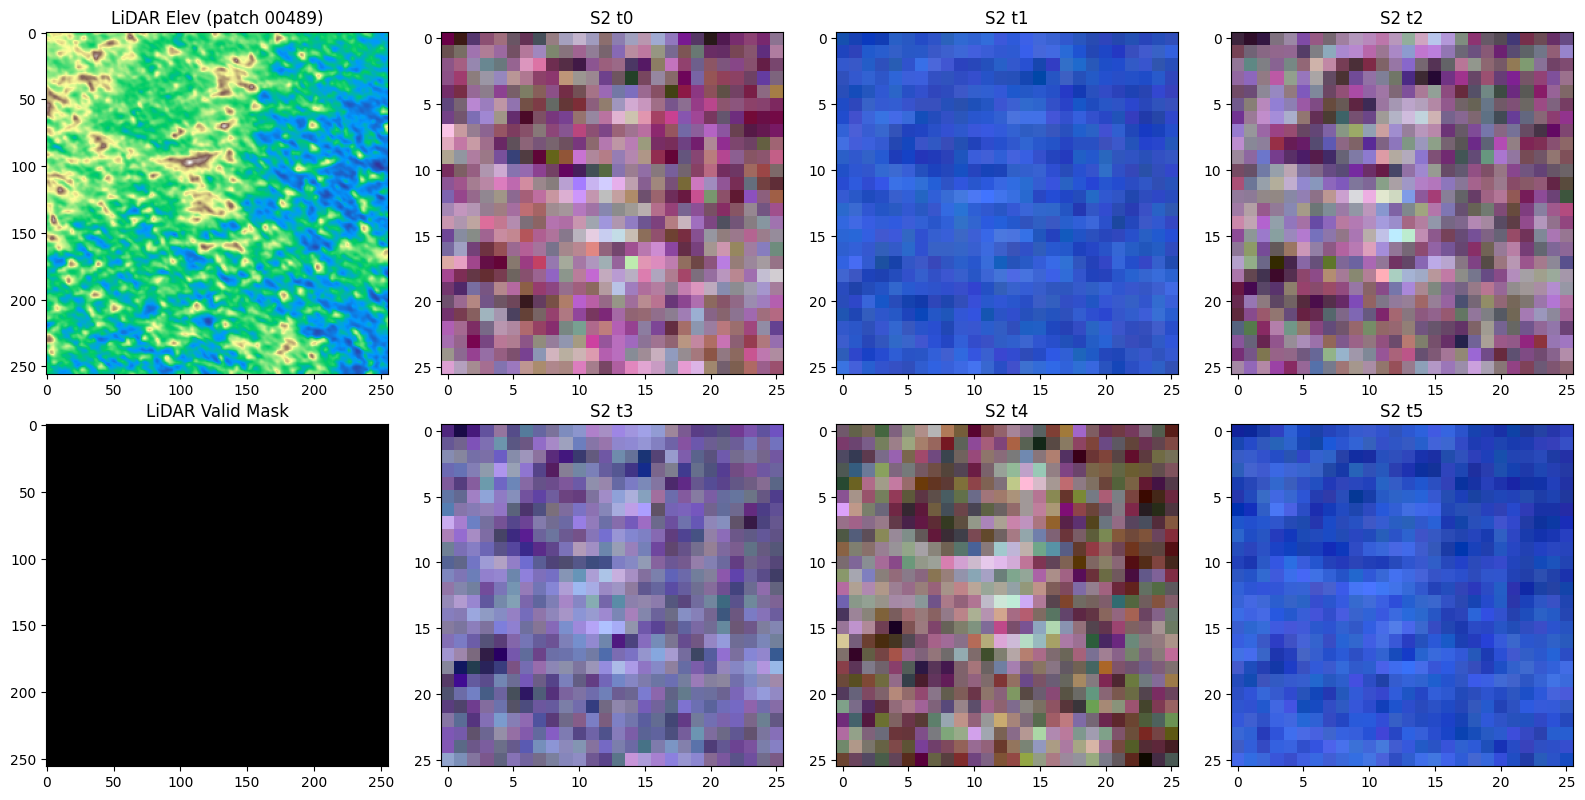

In [16]:
# Visualization
def normalize_01(img):
    img = img.astype(np.float32)
    mn, mx = np.nanmin(img), np.nanmax(img)
    if mx <= mn:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

def show_group(patch_id, out_lidar_dir, out_s2_dir):
    lid_path = os.path.join(out_lidar_dir, f"lidar_patch_{patch_id}.tif")
    s2_dir  = os.path.join(out_s2_dir, f"s2_patch_{patch_id}")

    with rasterio.open(lid_path) as src:
        lidar_elev = src.read(1)
        lidar_mask = src.read(2)

    s2_imgs = []
    for i in range(6):
        s2_path = os.path.join(s2_dir, f"t{i}.tif")
        with rasterio.open(s2_path) as src:
            rgb = src.read([1, 2, 3])
        rgb = np.moveaxis(rgb, 0, -1)
        s2_imgs.append(normalize_01(rgb))

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    ax = axes.ravel()

    im0 = ax[0].imshow(lidar_elev, cmap="terrain")
    ax[0].set_title(f"LiDAR Elev (patch {patch_id})")

    im1 = ax[4].imshow(lidar_mask, cmap="gray")
    ax[4].set_title("LiDAR Valid Mask")

    titles = [f"S2 t{i}" for i in range(6)]
    for i in range(3):
        ax[1 + i].imshow(s2_imgs[i])
        ax[1 + i].set_title(titles[i])

    for i in range(3, 6):
        ax[5 + (i - 3)].imshow(s2_imgs[i])
        ax[5 + (i - 3)].set_title(titles[i])

    for a in ax:
        if not hasattr(a.images, "__len__") or len(a.images) == 0:
            a.axis("off")

    plt.tight_layout()
    plt.show()

# Visualize first few samples
sample_lidar = sorted(glob(os.path.join(out_lidar_dir, "lidar_patch_*.tif")))[480:490]
for p in sample_lidar:
    pid = os.path.splitext(os.path.basename(p))[0].split("_")[-1]
    show_group(pid, out_lidar_dir, out_s2_dir)

# Additional Data Visualizations

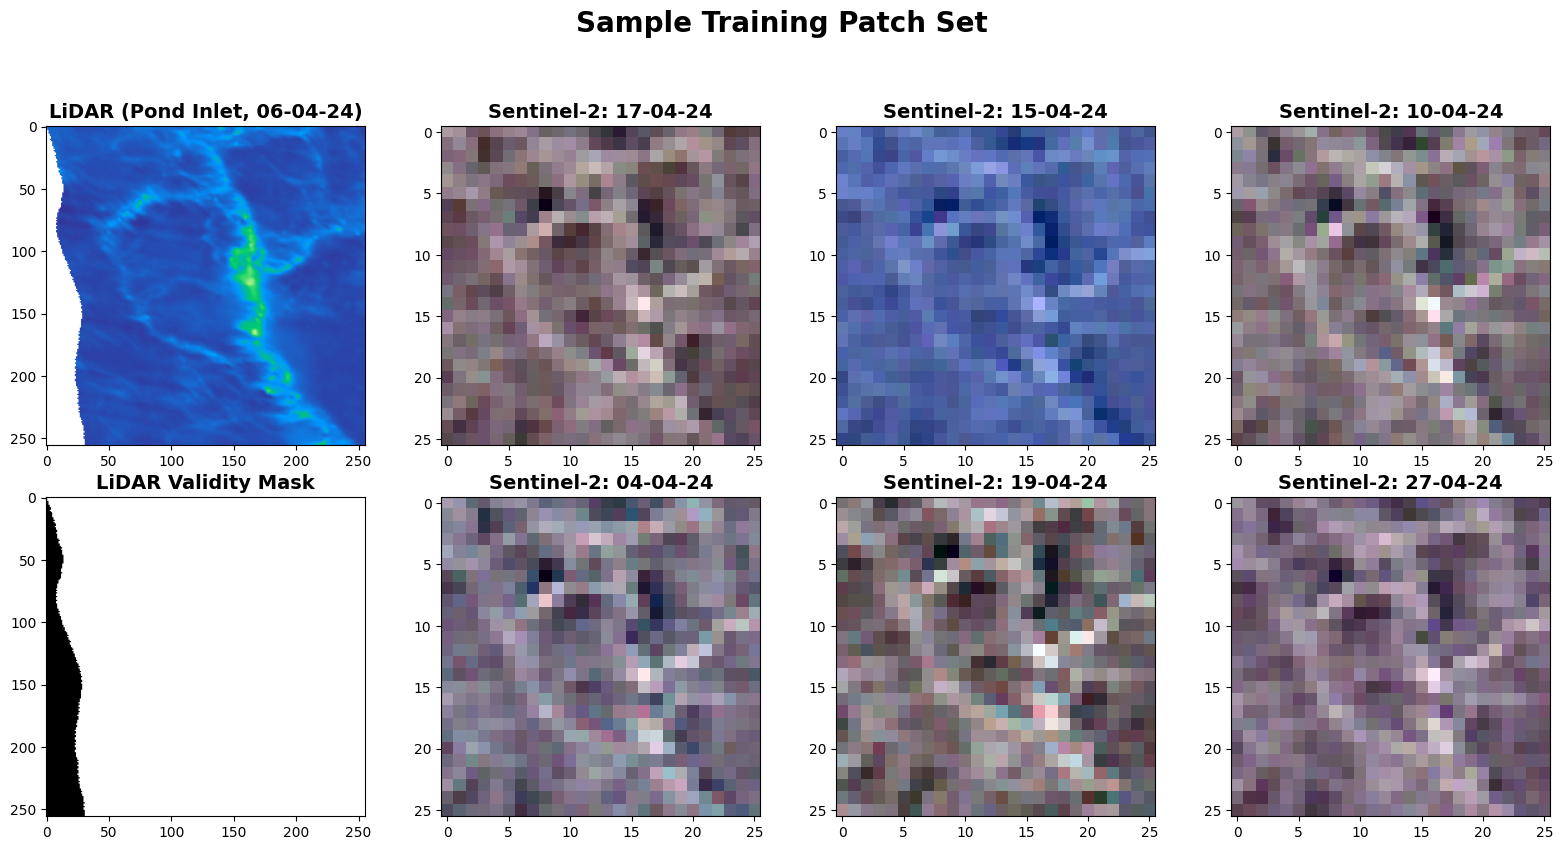

In [12]:
# Visualization

def normalize_01(img):
    img = img.astype(np.float32)
    mn, mx = np.nanmin(img), np.nanmax(img)
    if mx <= mn:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

def show_group(patch_id, out_lidar_dir, out_s2_dir):
    lid_path = os.path.join(out_lidar_dir, f"lidar_patch_{patch_id}.tif")
    s2_dir  = os.path.join(out_s2_dir, f"s2_patch_{patch_id}")
    
    with rasterio.open(lid_path) as src:
        lidar_elev = src.read(1)
        lidar_mask = src.read(2)
    
    s2_imgs = []
    for i in range(6):
        s2_path = os.path.join(s2_dir, f"t{i}.tif")
        with rasterio.open(s2_path) as src:
            rgb = src.read([1, 2, 3])
        rgb = np.moveaxis(rgb, 0, -1)
        s2_imgs.append(normalize_01(rgb))
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Sample Training Patch Set", fontsize=20, fontweight='bold', y=1.05)
    ax = axes.ravel()
    
    # Titles for each subplot in the requested order
    plot_titles = [
        "LiDAR (Pond Inlet, 06-04-24)",
        "Sentinel-2: 17-04-24",
        "Sentinel-2: 15-04-24",
        "Sentinel-2: 10-04-24",
        "LiDAR Validity Mask",
        "Sentinel-2: 04-04-24",
        "Sentinel-2: 19-04-24",
        "Sentinel-2: 27-04-24"
    ]
    
    # Order: elev, s2_0, s2_1, s2_2, mask, s2_3, s2_4, s2_5
    ax[0].imshow(lidar_elev, cmap="terrain")
    ax[0].set_title(plot_titles[0],fontsize=14,fontweight='bold')
    
    ax[1].imshow(s2_imgs[0])
    ax[1].set_title(plot_titles[1],fontsize=14,fontweight='bold')
    
    ax[2].imshow(s2_imgs[1])
    ax[2].set_title(plot_titles[2],fontsize=14,fontweight='bold')
    
    ax[3].imshow(s2_imgs[2])
    ax[3].set_title(plot_titles[3],fontsize=14,fontweight='bold')
    
    ax[4].imshow(lidar_mask, cmap="gray")
    ax[4].set_title(plot_titles[4],fontsize=14,fontweight='bold')
    
    ax[5].imshow(s2_imgs[3])
    ax[5].set_title(plot_titles[5],fontsize=14,fontweight='bold')
    
    ax[6].imshow(s2_imgs[4])
    ax[6].set_title(plot_titles[6],fontsize=14,fontweight='bold')
    
    ax[7].imshow(s2_imgs[5])
    ax[7].set_title(plot_titles[7],fontsize=14,fontweight='bold')
    
    for a in ax:
        if not hasattr(a.images, "__len__") or len(a.images) == 0:
            a.axis("off")
    
    plt.tight_layout()
    plt.show()

sample_lidar = glob(os.path.join(out_lidar_dir, "lidar_patch_13286.tif"))
pid = os.path.splitext(os.path.basename(sample_lidar[0]))[0].split("_")[-1]
show_group(pid, out_lidar_dir, out_s2_dir)

# 13286

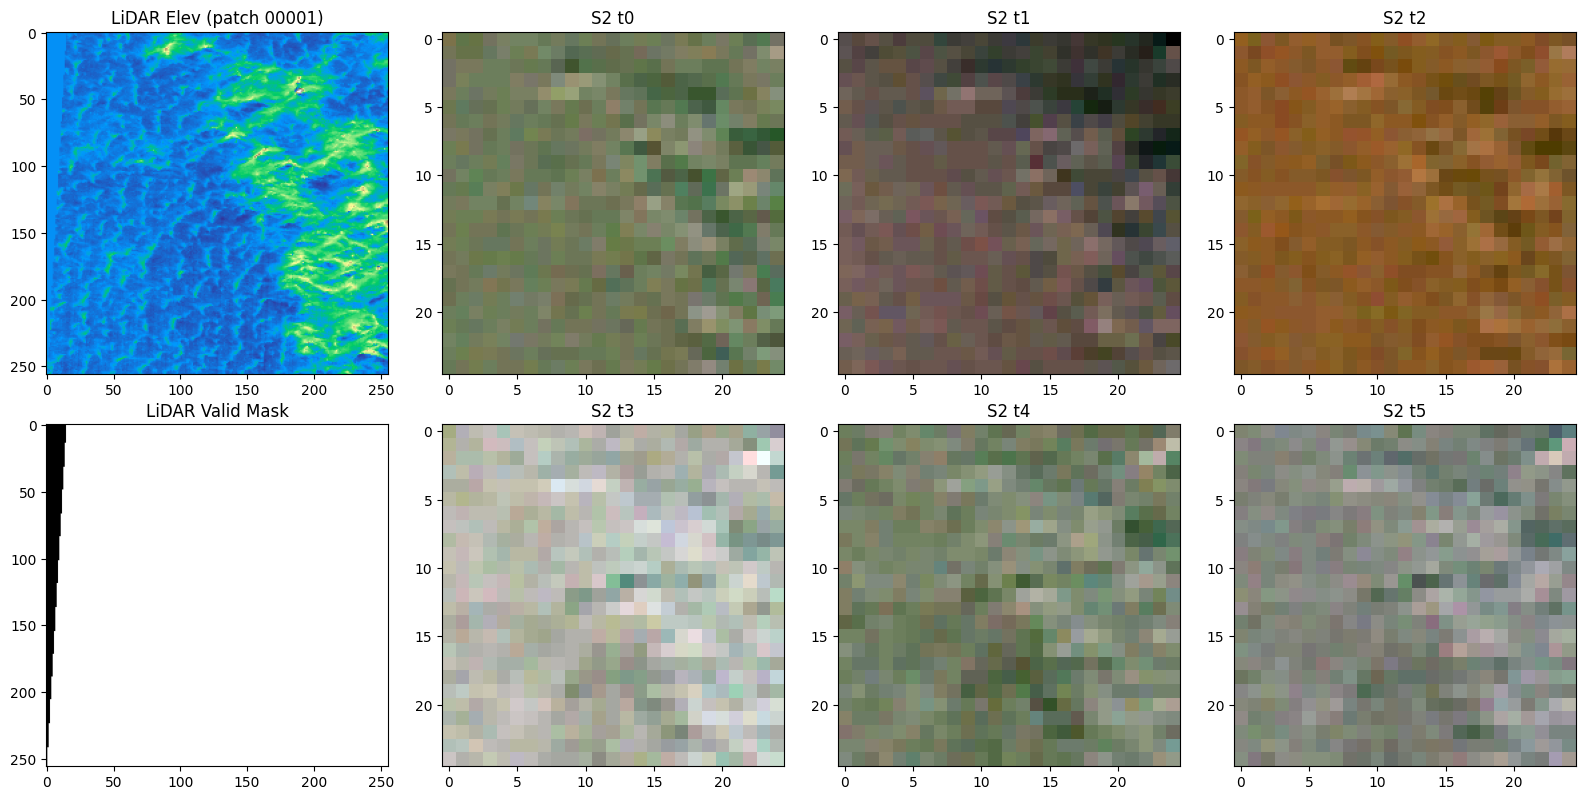

In [29]:
# Visualization with global normalization

def normalize_01(img):
    img = img.astype(np.float32)
    mn, mx = np.nanmin(img), np.nanmax(img)
    if mx <= mn:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

def normalize_global(img, global_min, global_max):
    img = img.astype(np.float32)
    return (img - global_min) / (global_max - global_min)

def show_group(patch_id, out_lidar_dir, out_s2_dir):
    lid_path = os.path.join(out_lidar_dir, f"lidar_patch_{patch_id}.tif")
    s2_dir  = os.path.join(out_s2_dir, f"s2_patch_{patch_id}")

    with rasterio.open(lid_path) as src:
        lidar_elev = src.read(1)
        lidar_mask = src.read(2)

    s2_imgs = []
    for i in range(6):
        s2_path = os.path.join(s2_dir, f"t{i}.tif")
        with rasterio.open(s2_path) as src:
            rgb = src.read([1, 2, 3])
        rgb = np.moveaxis(rgb, 0, -1)
        s2_imgs.append(rgb)

    # Compute global means
    # Compute global min/max for each band across all patches
    global_min = np.nanmin(s2_imgs, axis=(0, 1, 2))
    global_max = np.nanmax(s2_imgs, axis=(0, 1, 2))

    # normalize each image using global min/max
    for i in range(6):
        s2_imgs[i] = normalize_global(s2_imgs[i], global_min, global_max)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    ax = axes.ravel()

    im0 = ax[0].imshow(lidar_elev, cmap="terrain")
    ax[0].set_title(f"LiDAR Elev (patch {patch_id})")
    #plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[4].imshow(lidar_mask, cmap="gray")
    ax[4].set_title("LiDAR Valid Mask")
    #plt.colorbar(im1, ax=ax[4], fraction=0.046, pad=0.04)

    titles = [f"S2 t{i}" for i in range(6)]
    for i in range(3):
        ax[1 + i].imshow(s2_imgs[i])
        ax[1 + i].set_title(titles[i])
        ax[1 + i]

    for i in range(3, 6):
        ax[5 + (i - 3)].imshow(s2_imgs[i])
        ax[5 + (i - 3)].set_title(titles[i])
        ax[5 + (i - 3)]

    for a in ax:
        if not hasattr(a.images, "__len__") or len(a.images) == 0:
            a.axis("off")

    plt.tight_layout()
    plt.show()

# Example: Visualize example for report
sample_lidar = glob(os.path.join(out_lidar_dir, "lidar_patch_00001.tif"))
pid = os.path.splitext(os.path.basename(sample_lidar[0]))[0].split("_")[-1]
show_group(pid, out_lidar_dir, out_s2_dir)

In [ ]:
# Noise progression visualization

class LinearDiffusionScheduler:
    def __init__(self, timesteps=1000):
        self.betas = np.linspace(0.0001, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas)

    def add_noise(self, original_image, t):
        if t >= len(self.alphas_cumprod):
            t = len(self.alphas_cumprod) - 1
        alpha_bar_t = self.alphas_cumprod[t]
        noise = np.random.randn(*original_image.shape)
        noisy_image = np.sqrt(alpha_bar_t) * original_image + np.sqrt(1 - alpha_bar_t) * noise
        return noisy_image

class CosineDiffusionScheduler:
    def __init__(self, timesteps=1000):
        s = 0.008
        t_steps = np.arange(timesteps + 1)
        self.alphas_cumprod = np.cos(((t_steps / timesteps) + s) / (1 + s) * np.pi / 2) ** 2
        self.alphas_cumprod = self.alphas_cumprod / self.alphas_cumprod[0]

    def add_noise(self, original_image, t):
        if t >= len(self.alphas_cumprod):
            t = len(self.alphas_cumprod) - 1
        alpha_bar_t = self.alphas_cumprod[t]
        noise = np.random.randn(*original_image.shape)
        noisy_image = np.sqrt(alpha_bar_t) * original_image + np.sqrt(1 - alpha_bar_t) * noise
        return noisy_image

# Path to example LiDAR patch
REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
path_to_tif = os.path.join(REPO_DIR, "input_data", "lidar_patches_tuk", "lidar_patch_00014.tif")

# Load the LiDAR image
try:
    with rasterio.open(path_to_tif) as src:
        lidar_image = src.read(1)
except Exception as e:
    print(f"Error loading the .tif file: {e}")
    print("Using a placeholder image for demonstration.")
    lidar_image = np.random.rand(64, 64)

# Normalize image data to be between 0 and 1 for consistent plotting
min_val = lidar_image.min()
max_val = lidar_image.max()
lidar_image = (lidar_image - min_val) / (max_val - min_val)

# Define parameters for plotting
timesteps = 1000
num_samples_to_plot = 10
stride = timesteps // num_samples_to_plot
time_indices = np.arange(0, timesteps, stride)
if timesteps not in time_indices:
    time_indices = np.append(time_indices, timesteps)

# Initialize schedulers
linear_scheduler = LinearDiffusionScheduler(timesteps=timesteps)
cosine_scheduler = CosineDiffusionScheduler(timesteps=timesteps)

# Create the figure and subplots
fig, axes = plt.subplots(2, num_samples_to_plot+1, figsize=(15, 6))

# Plot for Linear Noise
for i, t_step in enumerate(time_indices):
    linear_noisy_image = linear_scheduler.add_noise(lidar_image, t=t_step)
    axes[0, i].imshow(linear_noisy_image, cmap='terrain',vmin=0, vmax=1)
    axes[0, i].set_title(f't={t_step}')
    axes[0, i].axis('off')

axes[0, 0].set_ylabel('Linear', rotation=90, size='large')
axes[0, 0].set_title(f'Original\nImage', fontsize=10)

# Plot for Cosine Noise
for i, t_step in enumerate(time_indices):
    cosine_noisy_image = cosine_scheduler.add_noise(lidar_image, t=t_step)
    axes[1, i].imshow(cosine_noisy_image, cmap='terrain',vmin=0, vmax=1)
    axes[1, i].set_title(f't={t_step}')
    axes[1, i].axis('off')

axes[1, 0].set_ylabel('Cosine', rotation=90, size='large')
axes[1, 0].set_title(f'Original\nImage', fontsize=10)

fig.suptitle('Noise Progression on Lidar Image', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('noise_progression_subplots.png')
print("Plot saved to noise_progression_subplots.png")
plt.show()